In [13]:
import tensorflow as tf
import tensorflow_datasets as tfds

In [14]:
train_data, validation_data, test_data = tfds.load(
    name="imdb_reviews",
    split=('train[:60%]', 'train[60%:]', 'test'),
    as_supervised=True
)

In [15]:
train_data
print("GPU is", "available" if tf.config.experimental.list_physical_devices("GPU") else "NOT AVAILABLE")

GPU is NOT AVAILABLE


In [16]:
vectorize_layer = tf.keras.layers.TextVectorization(
    max_tokens=20000,
    output_mode='int',
    output_sequence_length=300
)

In [17]:
train_text = train_data.map(lambda x, y: x)
vectorize_layer.adapt(train_text)

In [18]:
import numpy as np

embedding_index = {}

with open("glove.6B.100d.txt", encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coefs

# Get vocab
vocab = vectorize_layer.get_vocabulary()
print("Vocab size:", len(vocab))
word_index = dict(zip(vocab, range(len(vocab))))

embedding_dim = 100
embedding_matrix = np.zeros((len(vocab), embedding_dim))

for word, i in word_index.items():
    if word in embedding_index:
        embedding_matrix[i] = embedding_index[word]

Vocab size: 20000


In [28]:
def vectorize_text(text, label):
    text = tf.expand_dims(text, -1)   # ✅ REQUIRED here
    return vectorize_layer(text), label

train_data = train_data.map(vectorize_text)
validation_data = validation_data.map(vectorize_text)
test_data = test_data.map(vectorize_text)

In [29]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(
        input_dim=20000,
        output_dim=100,
        weights=[embedding_matrix],
        trainable=False
    ),

    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(64, return_sequences=True)
    ),

    tf.keras.layers.GlobalMaxPooling1D(),

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [30]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [31]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [32]:
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10



469/469 [==============================] - 58s 118ms/step - loss: 0.5792 - accuracy: 0.6845 - val_loss: 0.4618 - val_accuracy: 0.7843
Epoch 2/10
469/469 [==============================] - 55s 117ms/step - loss: 0.4421 - accuracy: 0.7985 - val_loss: 0.4102 - val_accuracy: 0.8107
Epoch 3/10
469/469 [==============================] - 56s 120ms/step - loss: 0.3923 - accuracy: 0.8264 - val_loss: 0.3803 - val_accuracy: 0.8266
Epoch 4/10
469/469 [==============================] - 58s 123ms/step - loss: 0.3643 - accuracy: 0.8417 - val_loss: 0.3640 - val_accuracy: 0.8352
Epoch 5/10
469/469 [==============================] - 58s 124ms/step - loss: 0.3381 - accuracy: 0.8561 - val_loss: 0.3486 - val_accuracy: 0.8467
Epoch 6/10
469/469 [==============================] - 60s 127ms/step - loss: 0.3180 - accuracy: 0.8653 - val_loss: 0.3395 - val_accuracy: 0.8529
Epoch 7/10
469/469 [==============================] - 60s 129ms/step - loss: 0.2936 - accuracy: 0.8772 - val_loss: 0.3325 - val_accuracy: 0.8

In [33]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

782/782 [==============================] - 29s 37ms/step - loss: 0.3170 - accuracy: 0.8635
Test Accuracy: 0.8635200262069702


In [34]:
import matplotlib.pyplot as plt

In [36]:
import os
os.makedirs('results', exist_ok=True)

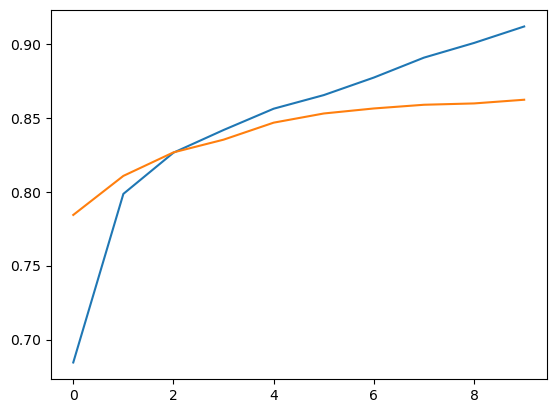

In [37]:
import os
import matplotlib.pyplot as plt

os.makedirs('results', exist_ok=True)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.savefig('results/accuracy.png')
plt.show()